## Dataset : IMDb Sentiment (50 000 critiques de films)

**Objectifs couverts :**
- Modèle de langage et factorisation par la règle de chaîne
- Perplexité
- RNN simple, LSTM, GRU (implémentation et comparaison)
- BPTT et gradient clipping
- Tokenisation, vocabulaire, padding, masquage, mini-lots
- Architecture Seq2Seq (encodeur–décodeur)
- Décodage glouton et Beam Search
- Métriques : perplexité & BLEU
- Réponse à la question de synthèse

1. Imports et configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import re
import time
import math
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch {torch.__version__} | Device : {DEVICE}')

# Style global des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
print('✅ Configuration terminée')

✅ PyTorch 2.11.0+cu128 | Device : cuda
✅ Configuration terminée



##  2. Chargement et exploration du dataset IMDb

In [ ]:
# Chargement
df = pd.read_csv('IMDB Dataset.csv')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
print(f"\nDistribution des sentiments:\n{df['sentiment'].value_counts()}")
df.head(3)

Shape : (50000, 2)
Colonnes : ['review', 'sentiment']

Distribution des sentiments:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


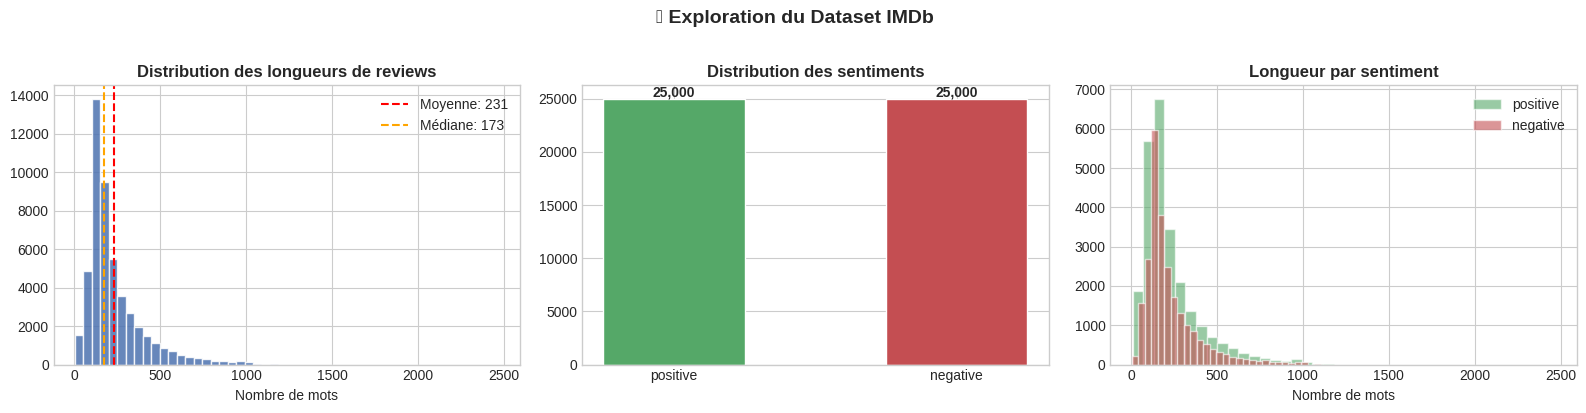


Stats longueur : min=4, max=2470, moy=231, std=171


In [ ]:
# Statistiques sur la longueur des reviews
df['length'] = df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme longueurs
axes[0].hist(df['length'], bins=50, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['length'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['length'].mean():.0f}")
axes[0].axvline(df['length'].median(), color='orange', linestyle='--', label=f"Médiane: {df['length'].median():.0f}")
axes[0].set_title('Distribution des longueurs de reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].legend()

# Distribution sentiments
counts = df['sentiment'].value_counts()
axes[1].bar(counts.index, counts.values, color=[COLORS[2], COLORS[3]], width=0.5, edgecolor='white')
axes[1].set_title('Distribution des sentiments', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate(counts.items()):
    axes[1].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

# Longueur par sentiment
for i, (sentiment, color) in enumerate(zip(['positive', 'negative'], [COLORS[2], COLORS[3]])):
    axes[2].hist(df[df['sentiment'] == sentiment]['length'], bins=40,
                 alpha=0.6, color=color, label=sentiment, edgecolor='white')
axes[2].set_title('Longueur par sentiment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Nombre de mots')
axes[2].legend()

plt.suptitle('📊 Exploration du Dataset IMDb', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_exploration_imdb.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nStats longueur : min={df['length'].min()}, max={df['length'].max()}, moy={df['length'].mean():.0f}, std={df['length'].std():.0f}")

---
## Modèle de Langage – Objectif probabiliste et perplexité

### 3.1 Factorisation par la règle de chaîne

Un **modèle de langage** estime la probabilité d'une séquence de tokens $w_1, w_2, \ldots, w_T$ :

$$P(w_1, w_2, \ldots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, \ldots, w_{t-1})$$

Cette factorisation vient de la **règle de chaîne des probabilités** :

$$P(A, B, C) = P(A) \cdot P(B|A) \cdot P(C|A,B)$$

L'entraînement minimise la **cross-entropie négative** :

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^T \log P(w_t \mid w_{1:t-1})$$

### 3.2 Perplexité

La **perplexité** mesure à quel point le modèle est « surpris » par le texte :

$$\text{PPL} = \exp\left(\mathcal{L}\right) = \exp\left(-\frac{1}{T}\sum_{t=1}^T \log P(w_t|w_{1:t-1})\right)$$

- PPL = 1 → modèle parfait (certitude absolue)
- PPL = |V| → modèle aléatoire uniforme (|V| = taille vocabulaire)
- **Plus la perplexité est basse, meilleur est le modèle**

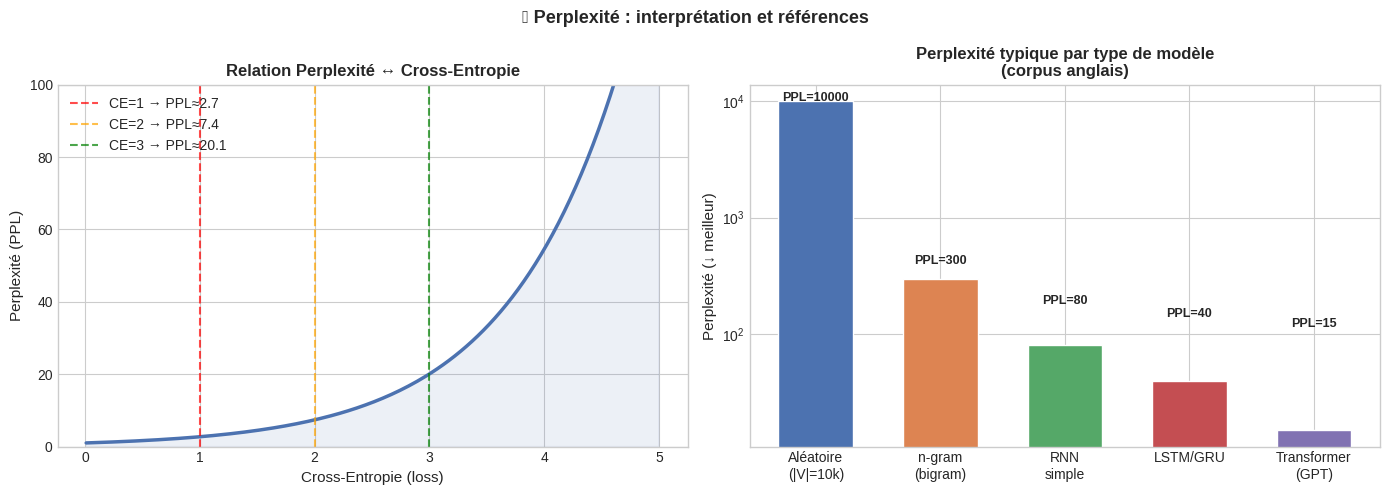

In [ ]:
# Illustration visuelle de la perplexité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe perplexité vs cross-entropie
ce_vals = np.linspace(0.01, 5, 200)
ppl_vals = np.exp(ce_vals)
axes[0].plot(ce_vals, ppl_vals, color=COLORS[0], linewidth=2.5)
axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='CE=1 → PPL≈2.7')
axes[0].axvline(x=2, color='orange', linestyle='--', alpha=0.7, label='CE=2 → PPL≈7.4')
axes[0].axvline(x=3, color='green', linestyle='--', alpha=0.7, label='CE=3 → PPL≈20.1')
axes[0].fill_between(ce_vals, ppl_vals, alpha=0.1, color=COLORS[0])
axes[0].set_xlabel('Cross-Entropie (loss)', fontsize=11)
axes[0].set_ylabel('Perplexité (PPL)', fontsize=11)
axes[0].set_title('Relation Perplexité ↔ Cross-Entropie', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].legend()

# Comparaison modèles typiques
models = ['Aléatoire\n(|V|=10k)', 'n-gram\n(bigram)', 'RNN\nsimple', 'LSTM/GRU', 'Transformer\n(GPT)']
ppls = [10000, 300, 80, 40, 15]
bars = axes[1].bar(models, ppls, color=COLORS[:5], edgecolor='white', width=0.6)
for bar, ppl in zip(bars, ppls):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'PPL={ppl}', ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylabel('Perplexité (↓ meilleur)', fontsize=11)
axes[1].set_title('Perplexité typique par type de modèle\n(corpus anglais)', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')

plt.suptitle('📐 Perplexité : interprétation et références', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_perplexite.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ⚙️ 4. Préparation des données : tokenisation, vocabulaire, padding

In [ ]:
# ── Nettoyage HTML et tokenisation simple ──────────────────────────────────
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)          # supprime balises HTML
    text = re.sub(r"[^a-zA-Z']", ' ', text)        # garde lettres
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['clean'] = df['review'].apply(clean_text)
df['tokens'] = df['clean'].apply(str.split)

# ── Construction du vocabulaire ────────────────────────────────────────────
MAX_VOCAB = 10_000
MAX_LEN   = 200      # longueur max après troncature

# Tokens spéciaux
PAD_TOKEN = '<PAD>'   # idx 0
UNK_TOKEN = '<UNK>'   # idx 1
BOS_TOKEN = '<BOS>'   # idx 2  (pour Seq2Seq)
EOS_TOKEN = '<EOS>'   # idx 3  (pour Seq2Seq)

all_tokens = [tok for tokens in df['tokens'] for tok in tokens]
freq = Counter(all_tokens)
vocab_words = [w for w, _ in freq.most_common(MAX_VOCAB - 4)]

word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1, BOS_TOKEN: 2, EOS_TOKEN: 3}
for w in vocab_words:
    word2idx[w] = len(word2idx)
idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Taille du vocabulaire : {VOCAB_SIZE:,}')
print(f'Tokens spéciaux : PAD={word2idx[PAD_TOKEN]}, UNK={word2idx[UNK_TOKEN]}, BOS={word2idx[BOS_TOKEN]}, EOS={word2idx[EOS_TOKEN]}')
print(f"\n20 mots les plus fréquents :")
print([w for w, _ in freq.most_common(20)])

Taille du vocabulaire : 10,000
Tokens spéciaux : PAD=0, UNK=1, BOS=2, EOS=3

20 mots les plus fréquents :
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not']


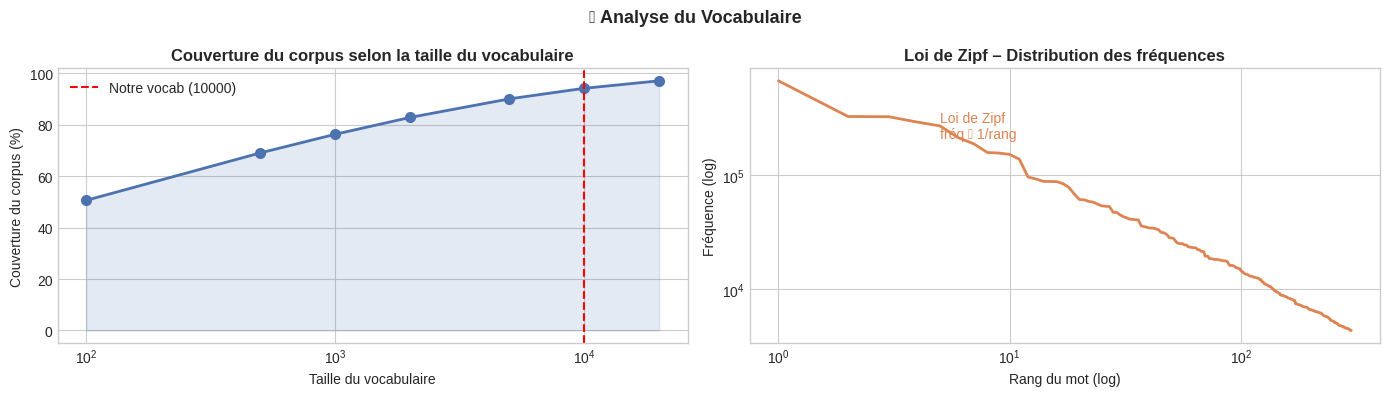

In [ ]:
# ── Encodage + troncature ─────────────────────────────────────────────────
def encode(tokens, max_len=MAX_LEN):
    ids = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens[:max_len]]
    return ids

df['ids']   = df['tokens'].apply(encode)
df['label'] = (df['sentiment'] == 'positive').astype(int)

# ── Visualisation : couverture du vocabulaire ──────────────────────────────
top_k = [100, 500, 1000, 2000, 5000, 10000, 20000]
coverage = []
total = sum(freq.values())
running = 0
sorted_freq = sorted(freq.values(), reverse=True)
for i, cnt in enumerate(sorted_freq):
    running += cnt
    if (i+1) in top_k:
        coverage.append(running / total * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(top_k[:len(coverage)], coverage, 'o-', color=COLORS[0], linewidth=2, markersize=7)
axes[0].axvline(x=MAX_VOCAB, color='red', linestyle='--', label=f'Notre vocab ({MAX_VOCAB})')
axes[0].fill_between(top_k[:len(coverage)], coverage, alpha=0.15, color=COLORS[0])
axes[0].set_xlabel('Taille du vocabulaire')
axes[0].set_ylabel('Couverture du corpus (%)')
axes[0].set_title('Couverture du corpus selon la taille du vocabulaire', fontweight='bold')
axes[0].legend()
axes[0].set_xscale('log')

# Distribution fréquences (loi de Zipf)
ranks = np.arange(1, 301)
freqs_top = [sorted_freq[i] for i in range(300)]
axes[1].loglog(ranks, freqs_top, color=COLORS[1], linewidth=2)
axes[1].set_xlabel('Rang du mot (log)')
axes[1].set_ylabel('Fréquence (log)')
axes[1].set_title('Loi de Zipf – Distribution des fréquences', fontweight='bold')
axes[1].text(5, freqs_top[5], 'Loi de Zipf\nfréq ∝ 1/rang', fontsize=10, color=COLORS[1])

plt.suptitle('📖 Analyse du Vocabulaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_vocabulaire.png', dpi=120, bbox_inches='tight')
plt.show()

Train : 40,000 | Val : 5,000 | Test : 5,000
Mini-lots entraînement : 625


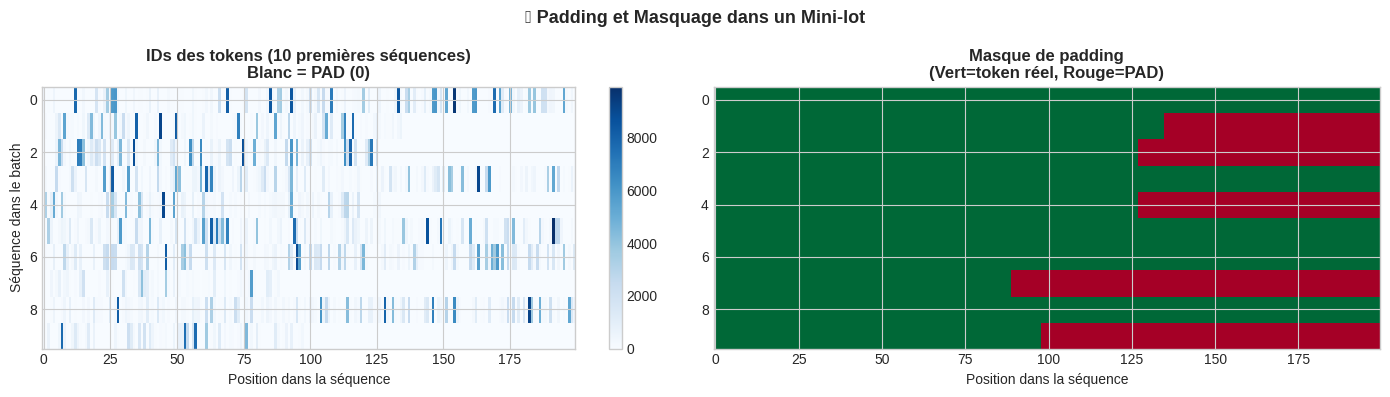

Shape du batch : torch.Size([64, 200]) | Longueurs : [200, 135, 127, 200, 127]


In [ ]:
# ── PyTorch Dataset & DataLoader avec padding + masquage ──────────────────
class IMDbDataset(Dataset):
    def __init__(self, ids_list, labels):
        self.ids    = ids_list
        self.labels = labels

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return torch.tensor(self.ids[idx], dtype=torch.long), self.labels[idx]

def collate_fn(batch):
    """Padding dynamique au sein d'un mini-lot."""
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True, padding_value=0)  # PAD_IDX = 0
    # masque : 1 là où vrai token, 0 là où PAD
    mask    = (padded != 0).float()
    return padded, torch.tensor(labels, dtype=torch.long), lengths, mask

# Split 80/10/10
from sklearn.model_selection import train_test_split
train_df, test_df  = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df,   test_df  = train_test_split(test_df, test_size=0.5, stratify=test_df['label'], random_state=42)

BATCH_SIZE = 64

train_loader = DataLoader(IMDbDataset(train_df['ids'].tolist(), train_df['label'].tolist()),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(IMDbDataset(val_df['ids'].tolist(), val_df['label'].tolist()),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(IMDbDataset(test_df['ids'].tolist(), test_df['label'].tolist()),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')
print(f'Mini-lots entraînement : {len(train_loader)}')

# Illustration du padding dans un mini-lot
sample_batch, sample_labels, sample_lengths, sample_mask = next(iter(train_loader))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Visualiser les 10 premières séquences du batch
show = 10
mat = sample_batch[:show].numpy()
mask_show = sample_mask[:show].numpy()
im = axes[0].imshow(mat, aspect='auto', cmap='Blues', interpolation='nearest')
axes[0].set_title(f'IDs des tokens (10 premières séquences)\nBlanc = PAD (0)', fontweight='bold')
axes[0].set_xlabel('Position dans la séquence')
axes[0].set_ylabel('Séquence dans le batch')
plt.colorbar(im, ax=axes[0])

axes[1].imshow(mask_show, aspect='auto', cmap='RdYlGn', interpolation='nearest', vmin=0, vmax=1)
axes[1].set_title('Masque de padding\n(Vert=token réel, Rouge=PAD)', fontweight='bold')
axes[1].set_xlabel('Position dans la séquence')

plt.suptitle('🔧 Padding et Masquage dans un Mini-lot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_padding_masquage.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Shape du batch : {sample_batch.shape} | Longueurs : {sample_lengths[:5].tolist()}')

---
##  5. Diagrammes d'architecture : RNN, LSTM, GRU

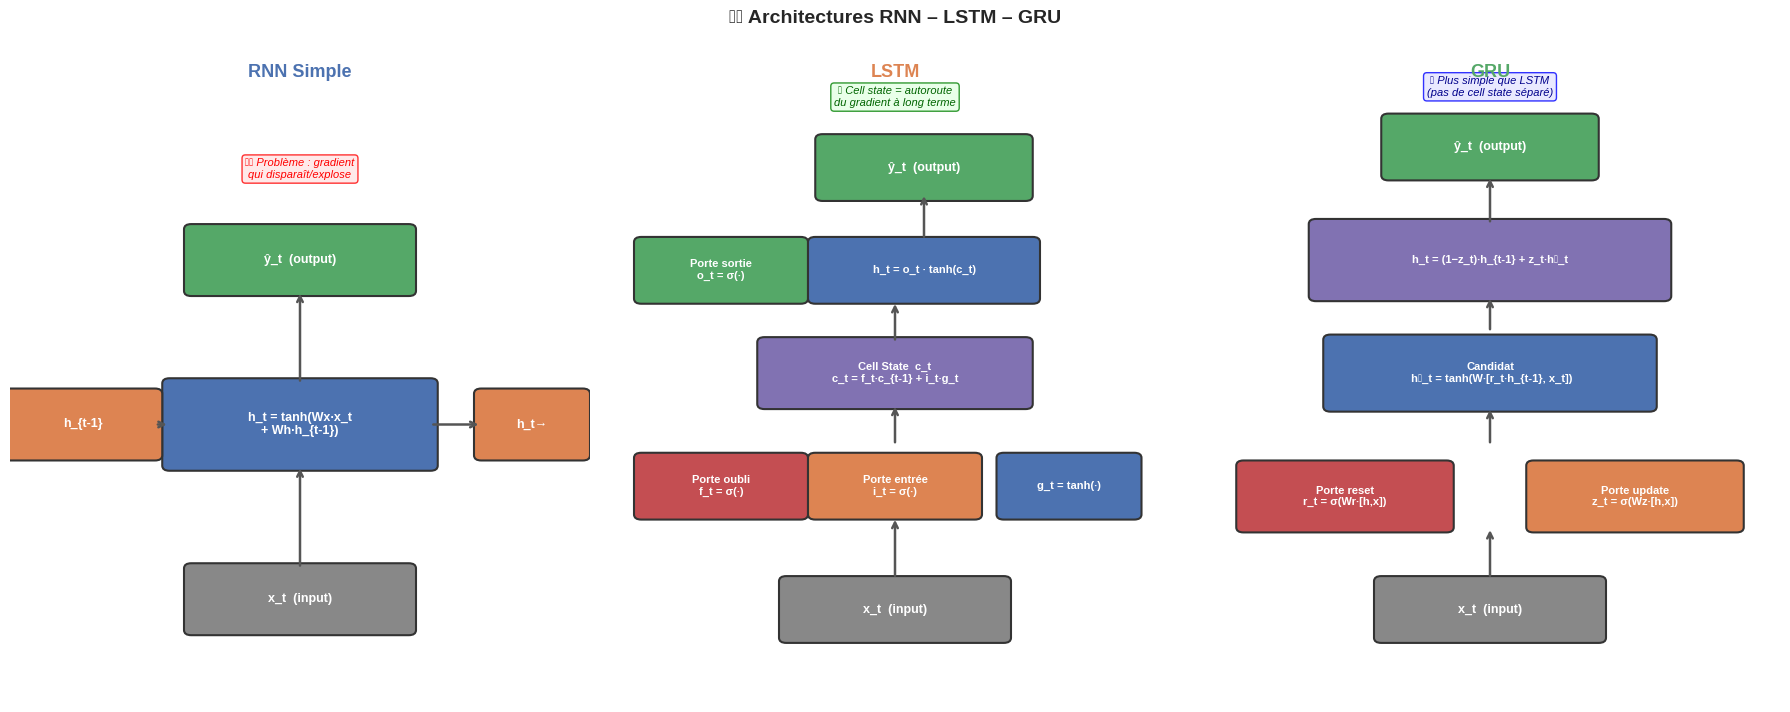

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

def draw_box(ax, x, y, w, h, text, color='#4C72B0', textcolor='white', fontsize=9):
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle="round,pad=0.05", linewidth=1.5,
                                    edgecolor='#333', facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=textcolor, fontweight='bold', zorder=4)

def arrow(ax, x1, y1, x2, y2, color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8), zorder=5)

# ── RNN simple ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(-0.5, 5.5)
ax.axis('off')
ax.set_title('RNN Simple', fontsize=13, fontweight='bold', color=COLORS[0])
# Entrée
draw_box(ax, 2, 0.5, 1.5, 0.6, 'x_t  (input)', '#888888')
# Cellule
draw_box(ax, 2, 2.2, 1.8, 0.8, 'h_t = tanh(Wx·x_t\n+ Wh·h_{t-1})', COLORS[0])
# État caché précédent
draw_box(ax, 0.5, 2.2, 1.0, 0.6, 'h_{t-1}', '#DD8452')
# Sortie
draw_box(ax, 2, 3.8, 1.5, 0.6, 'ŷ_t  (output)', '#55A868')
# État suivant
draw_box(ax, 3.6, 2.2, 0.7, 0.6, 'h_t→', '#DD8452')

arrow(ax, 2, 0.8, 2, 1.8); arrow(ax, 1.0, 2.2, 1.1, 2.2)
arrow(ax, 2, 2.6, 2, 3.5); arrow(ax, 2.9, 2.2, 3.25, 2.2)
ax.text(2, 4.6, '⚠️ Problème : gradient\nqui disparaît/explose', ha='center', fontsize=8,
        color='red', style='italic',
        bbox=dict(boxstyle='round', facecolor='#FFE4E4', edgecolor='red', alpha=0.8))

# ── LSTM ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(-0.5, 5.5)
ax.axis('off')
ax.set_title('LSTM', fontsize=13, fontweight='bold', color=COLORS[1])
draw_box(ax, 2, 0.4, 1.5, 0.55, 'x_t  (input)', '#888888')
# Portes
draw_box(ax, 0.8, 1.6, 1.1, 0.55, 'Porte oubli\nf_t = σ(·)', '#C44E52', fontsize=8)
draw_box(ax, 2.0, 1.6, 1.1, 0.55, 'Porte entrée\ni_t = σ(·)', '#DD8452', fontsize=8)
draw_box(ax, 3.2, 1.6, 0.9, 0.55, 'g_t = tanh(·)', '#4C72B0', fontsize=8)
# Cell state
draw_box(ax, 2.0, 2.7, 1.8, 0.6, 'Cell State  c_t\nc_t = f_t·c_{t-1} + i_t·g_t', '#8172B2', fontsize=8)
# Porte sortie
draw_box(ax, 0.8, 3.7, 1.1, 0.55, 'Porte sortie\no_t = σ(·)', '#55A868', fontsize=8)
draw_box(ax, 2.2, 3.7, 1.5, 0.55, 'h_t = o_t · tanh(c_t)', '#4C72B0', fontsize=8)
draw_box(ax, 2.2, 4.7, 1.4, 0.55, 'ŷ_t  (output)', '#55A868')

arrow(ax, 2, 0.7, 2, 1.3); arrow(ax, 2, 2.0, 2, 2.4)
arrow(ax, 2, 3.0, 2, 3.4); arrow(ax, 2.2, 4.0, 2.2, 4.45)
ax.text(2, 5.3, '✅ Cell state = autoroute\ndu gradient à long terme', ha='center', fontsize=8,
        color='darkgreen', style='italic',
        bbox=dict(boxstyle='round', facecolor='#E4FFE4', edgecolor='green', alpha=0.8))

# ── GRU ───────────────────────────────────────────────────────────────────
ax = axes[2]
ax.set_xlim(0, 4); ax.set_ylim(-0.5, 5.5)
ax.axis('off')
ax.set_title('GRU', fontsize=13, fontweight='bold', color=COLORS[2])
draw_box(ax, 2, 0.4, 1.5, 0.55, 'x_t  (input)', '#888888')
draw_box(ax, 1.0, 1.5, 1.4, 0.6, 'Porte reset\nr_t = σ(Wr·[h,x])', '#C44E52', fontsize=8)
draw_box(ax, 3.0, 1.5, 1.4, 0.6, 'Porte update\nz_t = σ(Wz·[h,x])', '#DD8452', fontsize=8)
draw_box(ax, 2.0, 2.7, 2.2, 0.65, 'Candidat\n h̃_t = tanh(W·[r_t·h_{t-1}, x_t])', '#4C72B0', fontsize=8)
draw_box(ax, 2.0, 3.8, 2.4, 0.7, 'h_t = (1−z_t)·h_{t-1} + z_t·h̃_t', '#8172B2', fontsize=8)
draw_box(ax, 2.0, 4.9, 1.4, 0.55, 'ŷ_t  (output)', '#55A868')

arrow(ax, 2, 0.7, 2, 1.2); arrow(ax, 2, 2.0, 2, 2.37)
arrow(ax, 2, 3.1, 2, 3.45); arrow(ax, 2, 4.15, 2, 4.62)
ax.text(2, 5.4, '✅ Plus simple que LSTM\n(pas de cell state séparé)', ha='center', fontsize=8,
        color='darkblue', style='italic',
        bbox=dict(boxstyle='round', facecolor='#E4E4FF', edgecolor='blue', alpha=0.8))

plt.suptitle('🏗️ Architectures RNN – LSTM – GRU', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_architectures_rnn_lstm_gru.png', dpi=120, bbox_inches='tight')
plt.show()

---
##  6. Implémentation : RNN simple, LSTM, GRU (Classification IMDb)

In [ ]:
class SentimentModel(nn.Module):
    """
    Modèle générique de classification de sentiment.
    cell_type : 'RNN' | 'LSTM' | 'GRU'
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers,
                 cell_type='LSTM', dropout=0.3, bidirectional=False):
        super().__init__()
        self.cell_type   = cell_type
        self.hidden_dim  = hidden_dim
        self.n_layers    = n_layers
        self.bidirectional = bidirectional
        D = 2 if bidirectional else 1

        # Couche d'embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Cellule récurrente
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[cell_type]
        self.rnn = rnn_cls(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * D, 2)

    def forward(self, x, lengths):
        emb = self.dropout(self.embedding(x))          # (B, T, E)

        # PackedSequence pour ignorer le padding
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

        if self.cell_type == 'LSTM':
            out, (hn, _) = self.rnn(packed)
        else:
            out, hn = self.rnn(packed)

        # Dernier état caché (toutes directions)
        if self.bidirectional:
            hn = torch.cat([hn[-2], hn[-1]], dim=1)   # (B, 2*H)
        else:
            hn = hn[-1]                                 # (B, H)

        logits = self.fc(self.dropout(hn))             # (B, 2)
        return logits

# ── Hyperparamètres ────────────────────────────────────────────────────────
EMBED_DIM  = 128
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.4
EPOCHS     = 5
LR         = 1e-3
CLIP       = 1.0        # gradient clipping

print('✅ Modèle SentimentModel défini')

✅ Modèle SentimentModel défini


In [ ]:
# ── Fonctions d'entraînement et d'évaluation ──────────────────────────────
def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y, lengths, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        # ── Gradient clipping ────────────────────────────────────────────
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y, lengths, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x, lengths)
            loss   = criterion(logits, y)
            total_loss += loss.item() * y.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total

def train_model(cell_type, clip=CLIP):
    model = SentimentModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS,
                           cell_type=cell_type, dropout=DROPOUT).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, t0 = 0, time.time()

    for epoch in range(1, EPOCHS + 1):
        tr_l, tr_a = train_epoch(model, train_loader, optimizer, criterion, clip)
        va_l, va_a = evaluate(model, val_loader, criterion)
        scheduler.step(va_l)
        history['train_loss'].append(tr_l); history['val_loss'].append(va_l)
        history['train_acc'].append(tr_a);  history['val_acc'].append(va_a)
        if va_a > best_val_acc:
            best_val_acc = va_a
        print(f'[{cell_type}] Epoch {epoch}/{EPOCHS} | '
              f'Loss {tr_l:.4f}/{va_l:.4f} | Acc {tr_a:.4f}/{va_a:.4f}')

    elapsed = time.time() - t0
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    _, test_acc = evaluate(model, test_loader, criterion)
    print(f'  → Test Acc : {test_acc:.4f} | Temps : {elapsed:.1f}s | Params : {n_params:,}\n')
    return model, history, elapsed, n_params, test_acc

print('✅ Fonctions définies – lancement de l\'entraînement...')

✅ Fonctions définies – lancement de l'entraînement...


In [ ]:
# ── Entraînement des trois architectures ──────────────────────────────────
results = {}
for cell in ['RNN', 'GRU', 'LSTM']:
    model, hist, elapsed, n_params, test_acc = train_model(cell)
    results[cell] = {'model': model, 'history': hist,
                     'time': elapsed, 'params': n_params, 'test_acc': test_acc}

[RNN] Epoch 1/5 | Loss 0.6920/0.6400 | Acc 0.5393/0.6510
[RNN] Epoch 2/5 | Loss 0.6688/0.6485 | Acc 0.5975/0.6546
[RNN] Epoch 3/5 | Loss 0.6540/0.6713 | Acc 0.6189/0.6012
[RNN] Epoch 4/5 | Loss 0.6075/0.5618 | Acc 0.6816/0.7230
[RNN] Epoch 5/5 | Loss 0.5779/0.5917 | Acc 0.7069/0.6934
  → Test Acc : 0.6932 | Temps : 68.0s | Params : 1,346,306

[GRU] Epoch 1/5 | Loss 0.6315/0.4961 | Acc 0.6339/0.7670
[GRU] Epoch 2/5 | Loss 0.4168/0.3294 | Acc 0.8097/0.8554
[GRU] Epoch 3/5 | Loss 0.3301/0.3467 | Acc 0.8566/0.8650
[GRU] Epoch 4/5 | Loss 0.2924/0.3157 | Acc 0.8763/0.8776
[GRU] Epoch 5/5 | Loss 0.2640/0.2761 | Acc 0.8903/0.8906
  → Test Acc : 0.8854 | Temps : 72.9s | Params : 1,478,402

[LSTM] Epoch 1/5 | Loss 0.6545/0.5988 | Acc 0.6098/0.6916
[LSTM] Epoch 2/5 | Loss 0.5327/0.4284 | Acc 0.7412/0.8154
[LSTM] Epoch 3/5 | Loss 0.4059/0.3447 | Acc 0.8197/0.8512
[LSTM] Epoch 4/5 | Loss 0.3428/0.3055 | Acc 0.8532/0.8732
[LSTM] Epoch 5/5 | Loss 0.3027/0.2869 | Acc 0.8744/0.8800
  → Test Acc : 0.876

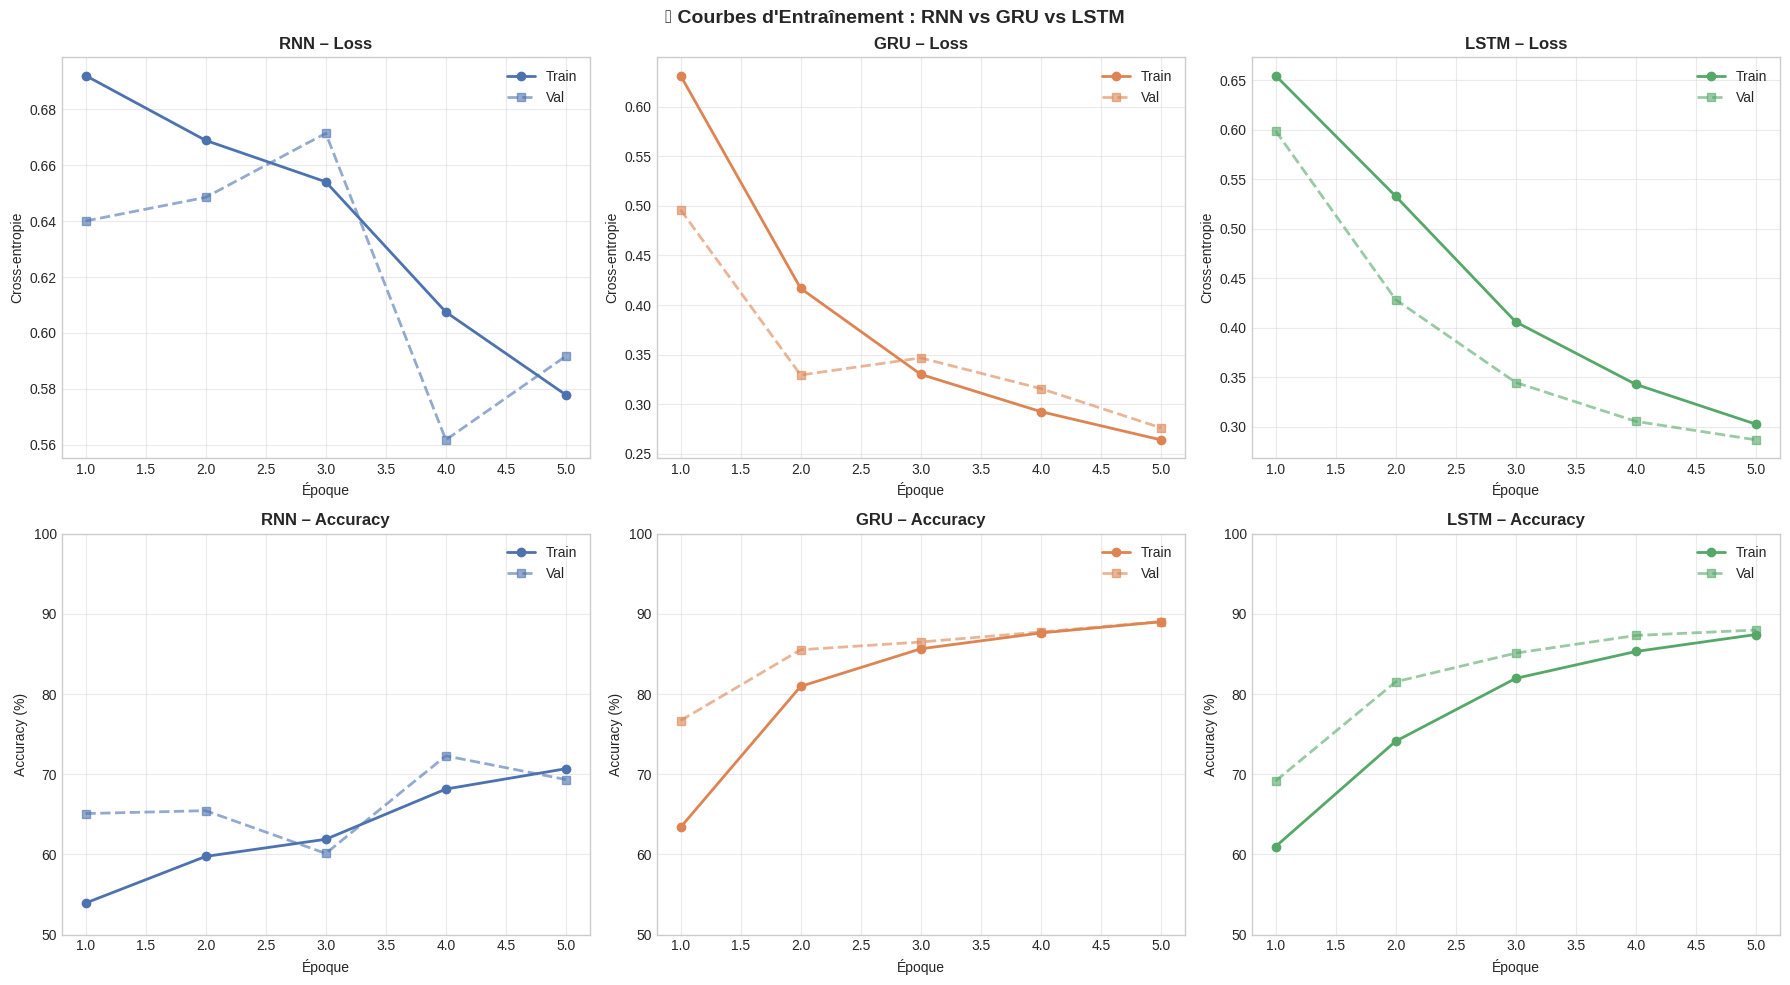

In [ ]:
# ── Visualisation comparaison ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
epochs_range = range(1, EPOCHS + 1)

for col, (cell, color) in enumerate(zip(['RNN', 'GRU', 'LSTM'], COLORS)):
    hist = results[cell]['history']
    # Courbes de loss
    axes[0, col].plot(epochs_range, hist['train_loss'], 'o-', color=color, label='Train', linewidth=2)
    axes[0, col].plot(epochs_range, hist['val_loss'],   's--', color=color, alpha=0.6, label='Val', linewidth=2)
    axes[0, col].set_title(f'{cell} – Loss', fontsize=12, fontweight='bold')
    axes[0, col].set_xlabel('Époque'); axes[0, col].set_ylabel('Cross-entropie')
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.4)
    # Courbes d'accuracy
    axes[1, col].plot(epochs_range, [a*100 for a in hist['train_acc']], 'o-', color=color, label='Train', linewidth=2)
    axes[1, col].plot(epochs_range, [a*100 for a in hist['val_acc']],   's--', color=color, alpha=0.6, label='Val', linewidth=2)
    axes[1, col].set_title(f'{cell} – Accuracy', fontsize=12, fontweight='bold')
    axes[1, col].set_xlabel('Époque'); axes[1, col].set_ylabel('Accuracy (%)')
    axes[1, col].set_ylim(50, 100)
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.4)

plt.suptitle('📈 Courbes d\'Entraînement : RNN vs GRU vs LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_courbes_entrainement.png', dpi=120, bbox_inches='tight')
plt.show()

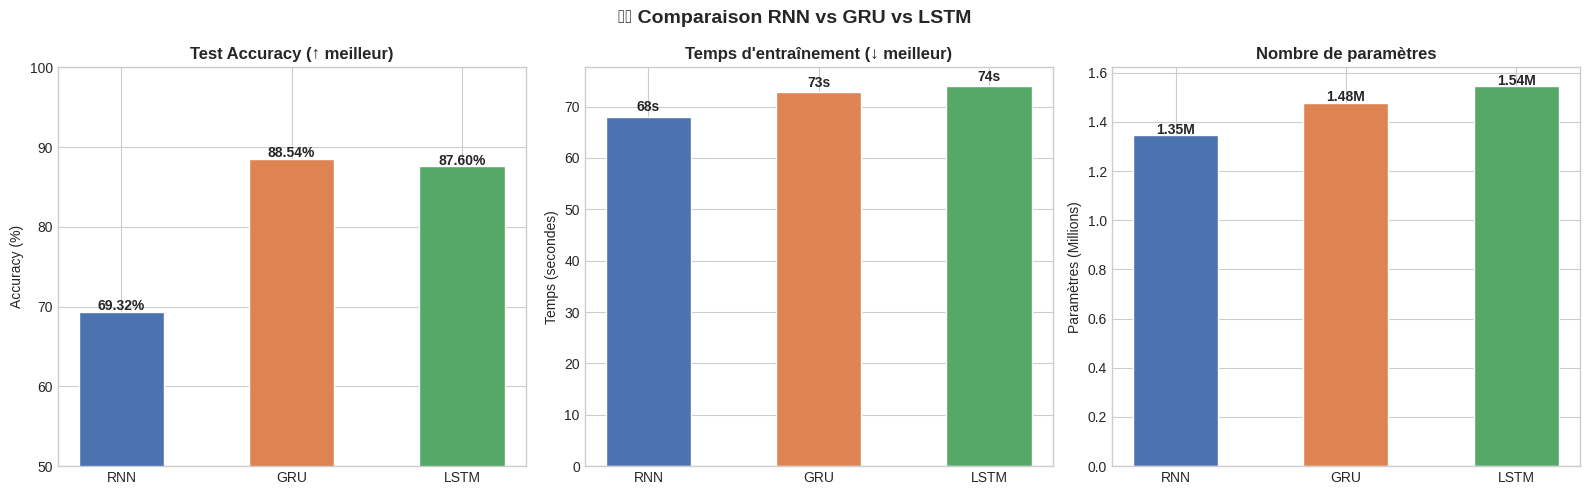


📊 Tableau récapitulatif :
Modèle         Test Acc    Temps (s)   Paramètres
--------------------------------------------------
RNN              69.32%        68.0s    1,346,306
GRU              88.54%        72.9s    1,478,402
LSTM             87.60%        73.9s    1,544,450


In [ ]:
# ── Tableau comparatif ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cells  = list(results.keys())
colors = COLORS[:3]
test_accs = [results[c]['test_acc'] * 100 for c in cells]
times     = [results[c]['time'] for c in cells]
params    = [results[c]['params'] / 1e6 for c in cells]

# Test Accuracy
bars = axes[0].bar(cells, test_accs, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Test Accuracy (↑ meilleur)', fontweight='bold')
axes[0].set_ylim(50, 100)

# Temps d'entraînement
bars = axes[1].bar(cells, times, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}s', ha='center', fontweight='bold')
axes[1].set_ylabel('Temps (secondes)')
axes[1].set_title('Temps d\'entraînement (↓ meilleur)', fontweight='bold')

# Nombre de paramètres
bars = axes[2].bar(cells, params, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, params):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}M', ha='center', fontweight='bold')
axes[2].set_ylabel('Paramètres (Millions)')
axes[2].set_title('Nombre de paramètres', fontweight='bold')

plt.suptitle('⚖️ Comparaison RNN vs GRU vs LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_comparaison_modeles.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📊 Tableau récapitulatif :')
print(f'{"Modèle":<10} {"Test Acc":>12} {"Temps (s)":>12} {"Paramètres":>12}')
print('-' * 50)
for cell in cells:
    r = results[cell]
    print(f'{cell:<10} {r["test_acc"]*100:>11.2f}% {r["time"]:>11.1f}s {r["params"]:>12,}')

---
##  7. BPTT et Gradient Clipping – Démonstration expérimentale

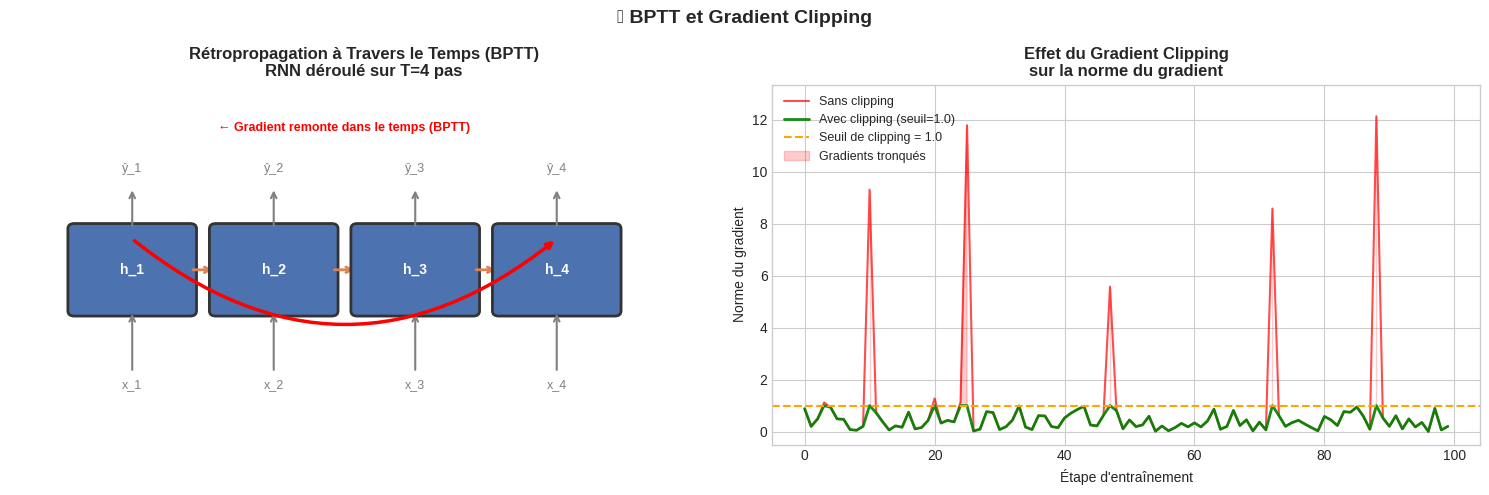

In [ ]:
# Illustration théorique BPTT
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Schéma BPTT déroulé ───────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 3); ax.axis('off')
ax.set_title('Rétropropagation à Travers le Temps (BPTT)\nRNN déroulé sur T=4 pas', fontweight='bold')

for t, label in enumerate(['t=1', 't=2', 't=3', 't=4']):
    # Cellule
    rect = mpatches.FancyBboxPatch((t*1.1, 0.8), 0.9, 0.8,
                                    boxstyle="round,pad=0.05", linewidth=2,
                                    edgecolor='#333', facecolor=COLORS[0], zorder=3)
    ax.add_patch(rect)
    ax.text(t*1.1 + 0.45, 1.2, f'h_{t+1}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # Entrée
    ax.annotate('', xy=(t*1.1 + 0.45, 0.8), xytext=(t*1.1 + 0.45, 0.2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(t*1.1 + 0.45, 0.05, f'x_{t+1}', ha='center', fontsize=9, color='gray')
    # Sortie
    ax.annotate('', xy=(t*1.1 + 0.45, 2.0), xytext=(t*1.1 + 0.45, 1.6),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(t*1.1 + 0.45, 2.15, f'ŷ_{t+1}', ha='center', fontsize=9, color='gray')
    # Flèche horizontale vers la prochaine cellule
    if t < 3:
        ax.annotate('', xy=((t+1)*1.1, 1.2), xytext=(t*1.1 + 0.9, 1.2),
                    arrowprops=dict(arrowstyle='->', color='#DD8452', lw=2))
# Flèche de rétropropagation
ax.annotate('', xy=(0.45, 1.5), xytext=(3.75, 1.5),
            arrowprops=dict(arrowstyle='<-', color='red', lw=2.5,
                            connectionstyle='arc3,rad=-0.4'))
ax.text(2.1, 2.55, '← Gradient remonte dans le temps (BPTT)',
        ha='center', fontsize=9, color='red', fontweight='bold')

# ── Effet du gradient clipping ─────────────────────────────────────────────
ax = axes[1]
np.random.seed(0)
steps = np.arange(100)
# Gradients sans clipping (explosif)
grads_no_clip = np.abs(np.random.randn(100)) * 0.5
# Ajouter quelques explosions
for i in [10, 25, 47, 72, 88]:
    grads_no_clip[i] += np.random.uniform(5, 15)
# Gradients avec clipping
grads_clipped = np.clip(grads_no_clip, 0, CLIP)

ax.plot(steps, grads_no_clip, color='red',   alpha=0.7, linewidth=1.5, label='Sans clipping')
ax.plot(steps, grads_clipped, color='green', alpha=0.9, linewidth=2,   label=f'Avec clipping (seuil={CLIP})')
ax.axhline(y=CLIP, color='orange', linestyle='--', linewidth=1.5, label=f'Seuil de clipping = {CLIP}')
ax.fill_between(steps, grads_no_clip, grads_clipped, where=grads_no_clip > CLIP,
                alpha=0.2, color='red', label='Gradients tronqués')
ax.set_xlabel('Étape d\'entraînement')
ax.set_ylabel('Norme du gradient')
ax.set_title('Effet du Gradient Clipping\nsur la norme du gradient', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, max(grads_no_clip) * 1.1)

plt.suptitle('⚡ BPTT et Gradient Clipping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_bptt_gradient_clipping.png', dpi=120, bbox_inches='tight')
plt.show()

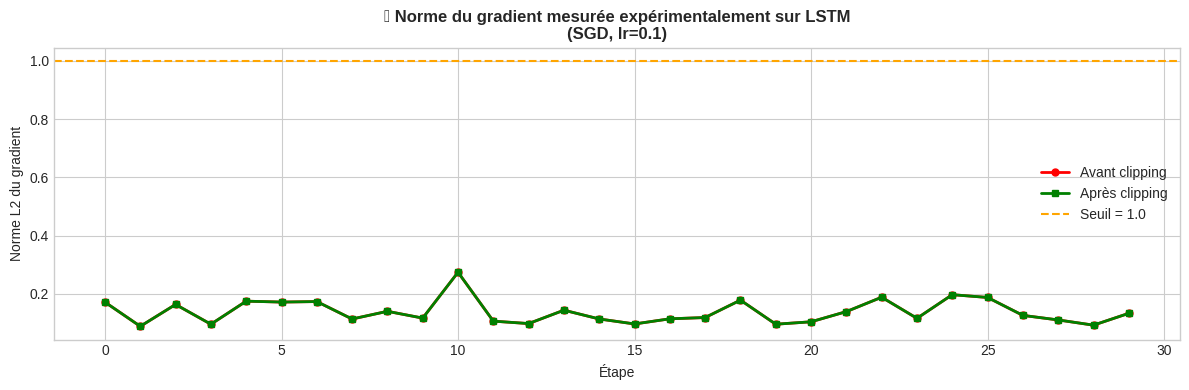

Norme max sans clipping : 0.274
Norme max avec clipping : 0.274


In [ ]:
# Mesure expérimentale : gradient norm avec/sans clipping sur LSTM
model_exp = SentimentModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, 2,
                            cell_type='LSTM', dropout=0.3).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_exp.parameters(), lr=0.1)  # SGD amplifie l'explosion

grad_norms_no_clip = []
grad_norms_clipped = []
N_STEPS = 30

loader_iter = iter(train_loader)
for step in range(N_STEPS):
    try:
        x, y, lengths, _ = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        x, y, lengths, _ = next(loader_iter)

    x, y = x.to(DEVICE), y.to(DEVICE)
    optimizer.zero_grad()
    logits = model_exp(x, lengths)
    loss = criterion(logits, y)
    loss.backward()

    # Norme avant clipping
    total_norm = sum(p.grad.norm().item()**2 for p in model_exp.parameters()
                     if p.grad is not None) ** 0.5
    grad_norms_no_clip.append(total_norm)

    # Clipping
    nn.utils.clip_grad_norm_(model_exp.parameters(), 1.0)
    total_norm_c = sum(p.grad.norm().item()**2 for p in model_exp.parameters()
                       if p.grad is not None) ** 0.5
    grad_norms_clipped.append(total_norm_c)
    optimizer.step()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grad_norms_no_clip, 'o-', color='red',   label='Avant clipping', linewidth=2, markersize=5)
ax.plot(grad_norms_clipped, 's-', color='green', label='Après clipping',  linewidth=2, markersize=5)
ax.axhline(y=1.0, color='orange', linestyle='--', linewidth=1.5, label='Seuil = 1.0')
ax.set_xlabel('Étape')
ax.set_ylabel('Norme L2 du gradient')
ax.set_title('📏 Norme du gradient mesurée expérimentalement sur LSTM\n(SGD, lr=0.1)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('09_gradient_clipping_exp.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Norme max sans clipping : {max(grad_norms_no_clip):.3f}')
print(f'Norme max avec clipping : {max(grad_norms_clipped):.3f}')

## Architecture Seq2Seq avec Teacher Forcing

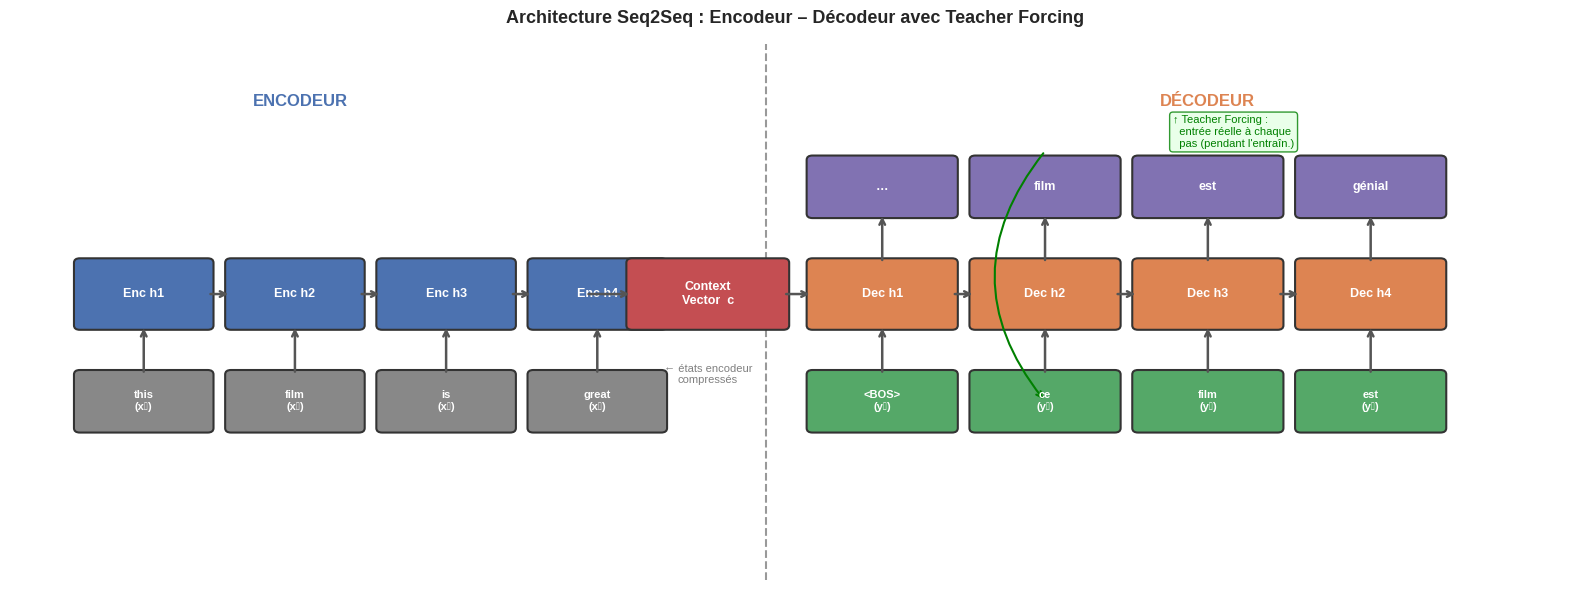

In [ ]:
# Diagramme Seq2Seq
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.set_xlim(-0.5, 13); ax.set_ylim(-1, 5); ax.axis('off')
ax.set_title('Architecture Seq2Seq : Encodeur – Décodeur avec Teacher Forcing',
             fontsize=13, fontweight='bold', pad=15)

# Encodeur
for i, (tok, lbl) in enumerate(zip(['this', 'film', 'is', 'great'], ['x₁','x₂','x₃','x₄'])):
    draw_box(ax, i*1.3 + 0.65, 1.0, 1.1, 0.6, f'{tok}\n({lbl})', '#888888', fontsize=8)
    draw_box(ax, i*1.3 + 0.65, 2.2, 1.1, 0.7, f'Enc h{i+1}', COLORS[0], fontsize=9)
    arrow(ax, i*1.3 + 0.65, 1.3, i*1.3 + 0.65, 1.85)
    if i > 0:
        arrow(ax, (i-1)*1.3 + 0.65 + 0.55, 2.2, i*1.3 + 0.65 - 0.55, 2.2)

# Vecteur de contexte
draw_box(ax, 5.5, 2.2, 1.3, 0.7, 'Context\nVector  c', '#C44E52', fontsize=9)
arrow(ax, 3.9 + 0.55, 2.2, 4.85, 2.2)
ax.text(5.5, 1.2, '← états encodeur\ncompressés', ha='center', fontsize=8, color='gray')

# Décodeur
for i, (tok, lbl) in enumerate(zip(['<BOS>', 'ce', 'film', 'est'], ['y₀','y₁','y₂','y₃'])):
    x_pos = i*1.4 + 7.0
    draw_box(ax, x_pos, 1.0, 1.2, 0.6, f'{tok}\n({lbl})', '#55A868', '#fff', fontsize=8)
    draw_box(ax, x_pos, 2.2, 1.2, 0.7, f'Dec h{i+1}', '#DD8452', fontsize=9)
    draw_box(ax, x_pos, 3.4, 1.2, 0.6, f'génial' if i==3 else ['ce','film','est'][i] if i>0 else '…',
             '#8172B2', fontsize=9)
    arrow(ax, x_pos, 1.3, x_pos, 1.85)
    arrow(ax, x_pos, 2.55, x_pos, 3.1)
    if i > 0:
        arrow(ax, (i-1)*1.4 + 7.0 + 0.6, 2.2, i*1.4 + 7.0 - 0.6, 2.2)

# Context -> décodeur
arrow(ax, 6.15, 2.2, 7.0 - 0.6, 2.2)

# Teacher forcing annotation
ax.annotate('', xy=(8.4, 1.0), xytext=(8.4, 3.8),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5,
                            connectionstyle='arc3,rad=0.4'))
ax.text(9.5, 3.85, '↑ Teacher Forcing :\n  entrée réelle à chaque\n  pas (pendant l\'entraîn.)',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round', facecolor='#E4FFE4', edgecolor='green', alpha=0.8))

# Séparateur
ax.axvline(x=6.0, color='black', linestyle='--', linewidth=1.5, alpha=0.4)
ax.text(2.0, 4.3, 'ENCODEUR', fontsize=12, fontweight='bold', color=COLORS[0], ha='center')
ax.text(9.8, 4.3, 'DÉCODEUR', fontsize=12, fontweight='bold', color='#DD8452', ha='center')

plt.tight_layout()
plt.savefig('10_seq2seq_architecture.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Implémentation Seq2Seq pour génération de texte (sur IMDb) ─────────────
# Tâche : modèle de langage génératif (prédiction du prochain token)

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn       = nn.LSTM(embed_dim, hidden_dim, n_layers,
                                  batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(),
                                                    batch_first=True, enforce_sorted=False)
        _, (hidden, cell) = self.rnn(packed)
        return hidden, cell   # context vectors


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn       = nn.LSTM(embed_dim, hidden_dim, n_layers,
                                  batch_first=True, dropout=dropout if n_layers > 1 else 0)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, token, hidden, cell):
        # token : (B,) → (B, 1)
        emb = self.dropout(self.embedding(token.unsqueeze(1)))
        out, (hidden, cell) = self.rnn(emb, (hidden, cell))
        pred = self.fc_out(out.squeeze(1))   # (B, vocab_size)
        return pred, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.5):
        B, T_trg = trg.shape
        vocab_size  = self.decoder.fc_out.out_features
        outputs     = torch.zeros(B, T_trg, vocab_size).to(src.device)

        hidden, cell = self.encoder(src, src_lengths)
        token        = trg[:, 0]    # <BOS>

        for t in range(1, T_trg):
            pred, hidden, cell = self.decoder(token, hidden, cell)
            outputs[:, t] = pred
            use_teacher  = torch.rand(1).item() < teacher_forcing_ratio
            token        = trg[:, t] if use_teacher else pred.argmax(1)

        return outputs


# ── Dataset pour tâche de génération (prochain token) ─────────────────────
class LMDataset(Dataset):
    """Source = tokens[:-1], Cible = tokens[1:] (décalage d'un pas)."""
    def __init__(self, ids_list, max_len=80):
        self.data = []
        bos, eos = word2idx[BOS_TOKEN], word2idx[EOS_TOKEN]
        for ids in ids_list:
            seq = [bos] + ids[:max_len] + [eos]
            if len(seq) >= 4:
                self.data.append(seq)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq = torch.tensor(self.data[idx], dtype=torch.long)
        return seq[:-1], seq[1:]   # (src, trg)

def lm_collate(batch):
    srcs, trgs = zip(*batch)
    lengths = torch.tensor([len(s) for s in srcs])
    src_pad = pad_sequence(srcs, batch_first=True, padding_value=0)
    trg_pad = pad_sequence(trgs, batch_first=True, padding_value=0)
    return src_pad, trg_pad, lengths

lm_train = LMDataset(train_df['ids'].tolist())
lm_val   = LMDataset(val_df['ids'].tolist())
lm_train_loader = DataLoader(lm_train, batch_size=64, shuffle=True,  collate_fn=lm_collate)
lm_val_loader   = DataLoader(lm_val,   batch_size=64, shuffle=False, collate_fn=lm_collate)
print(f'LM Dataset — train : {len(lm_train):,} | val : {len(lm_val):,}')

LM Dataset — train : 40,000 | val : 5,000


In [ ]:
# ── Entraînement Seq2Seq ───────────────────────────────────────────────────
ENC_HIDDEN = 128; DEC_HIDDEN = 128; S2S_LAYERS = 2; S2S_DROP = 0.3

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, ENC_HIDDEN, S2S_LAYERS, S2S_DROP)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, DEC_HIDDEN, S2S_LAYERS, S2S_DROP)
seq2seq = Seq2Seq(encoder, decoder).to(DEVICE)

n_params_s2s = sum(p.numel() for p in seq2seq.parameters() if p.requires_grad)
print(f'Seq2Seq paramètres : {n_params_s2s:,}')

optimizer_s2s = optim.Adam(seq2seq.parameters(), lr=1e-3)
criterion_s2s = nn.CrossEntropyLoss(ignore_index=0)    # ignore PAD

S2S_EPOCHS = 5
s2s_train_losses, s2s_val_losses = [], []
s2s_train_ppls,   s2s_val_ppls   = [], []

for epoch in range(1, S2S_EPOCHS + 1):
    seq2seq.train()
    t_loss, n_batches = 0, 0
    for src, trg, lengths in lm_train_loader:
        src, trg = src.to(DEVICE), trg.to(DEVICE)
        optimizer_s2s.zero_grad()
        outputs = seq2seq(src, lengths, trg, teacher_forcing_ratio=0.5)
        B, T, V = outputs.shape
        loss = criterion_s2s(outputs[:, 1:].reshape(-1, V), trg[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_s2s.step()
        t_loss += loss.item(); n_batches += 1
    t_loss /= n_batches

    seq2seq.eval(); v_loss, v_batches = 0, 0
    with torch.no_grad():
        for src, trg, lengths in lm_val_loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            outputs = seq2seq(src, lengths, trg, teacher_forcing_ratio=0.0)
            B, T, V = outputs.shape
            loss = criterion_s2s(outputs[:, 1:].reshape(-1, V), trg[:, 1:].reshape(-1))
            v_loss += loss.item(); v_batches += 1
    v_loss /= v_batches

    s2s_train_losses.append(t_loss); s2s_val_losses.append(v_loss)
    s2s_train_ppls.append(math.exp(t_loss)); s2s_val_ppls.append(math.exp(v_loss))
    print(f'[Seq2Seq] Epoch {epoch}/{S2S_EPOCHS} | '
          f'Train Loss={t_loss:.4f} PPL={math.exp(t_loss):.1f} | '
          f'Val Loss={v_loss:.4f} PPL={math.exp(v_loss):.1f}')

Seq2Seq paramètres : 4,378,384
[Seq2Seq] Epoch 1/5 | Train Loss=6.4473 PPL=631.0 | Val Loss=6.3100 PPL=550.1
[Seq2Seq] Epoch 2/5 | Train Loss=6.1210 PPL=455.3 | Val Loss=6.2750 PPL=531.1
[Seq2Seq] Epoch 3/5 | Train Loss=5.9847 PPL=397.3 | Val Loss=6.2398 PPL=512.8
[Seq2Seq] Epoch 4/5 | Train Loss=5.9044 PPL=366.6 | Val Loss=6.2224 PPL=503.9
[Seq2Seq] Epoch 5/5 | Train Loss=5.8408 PPL=344.0 | Val Loss=6.1824 PPL=484.1


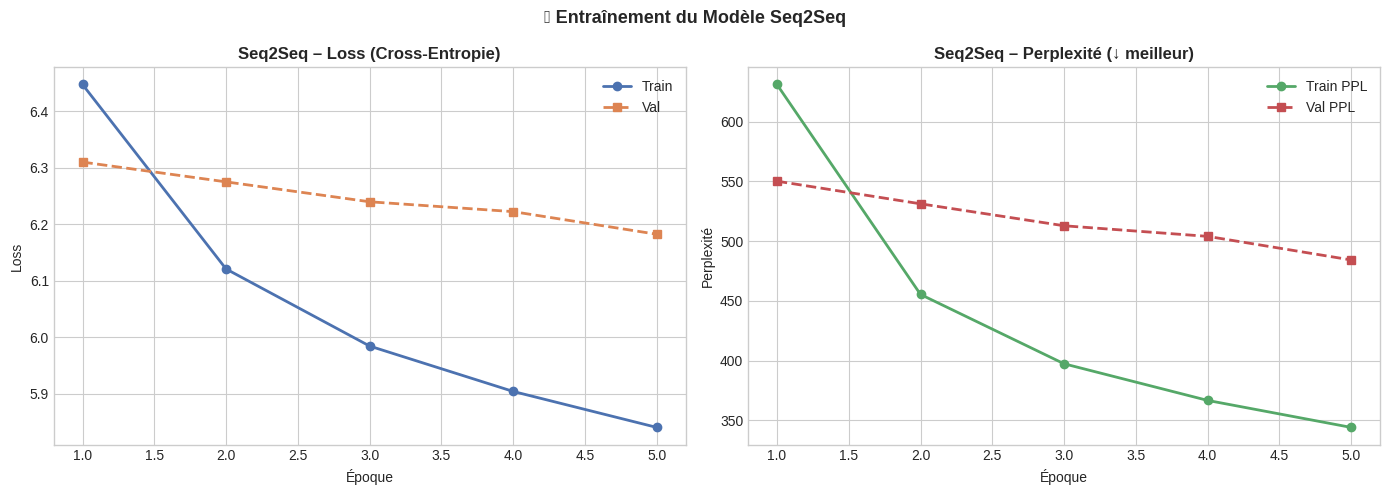

Perplexité finale : Train=344.0 | Val=484.1


In [ ]:
# Courbes Seq2Seq
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, S2S_EPOCHS + 1)

axes[0].plot(ep, s2s_train_losses, 'o-', color=COLORS[0], label='Train', linewidth=2)
axes[0].plot(ep, s2s_val_losses,   's--', color=COLORS[1], label='Val',   linewidth=2)
axes[0].set_title('Seq2Seq – Loss (Cross-Entropie)', fontweight='bold')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ep, s2s_train_ppls, 'o-', color=COLORS[2], label='Train PPL', linewidth=2)
axes[1].plot(ep, s2s_val_ppls,   's--', color=COLORS[3], label='Val PPL',   linewidth=2)
axes[1].set_title('Seq2Seq – Perplexité (↓ meilleur)', fontweight='bold')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Perplexité')
axes[1].legend()

plt.suptitle('📉 Entraînement du Modèle Seq2Seq', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_seq2seq_training.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Perplexité finale : Train={s2s_train_ppls[-1]:.1f} | Val={s2s_val_ppls[-1]:.1f}')

---
##  9. Stratégies de Décodage : Glouton vs Beam Search

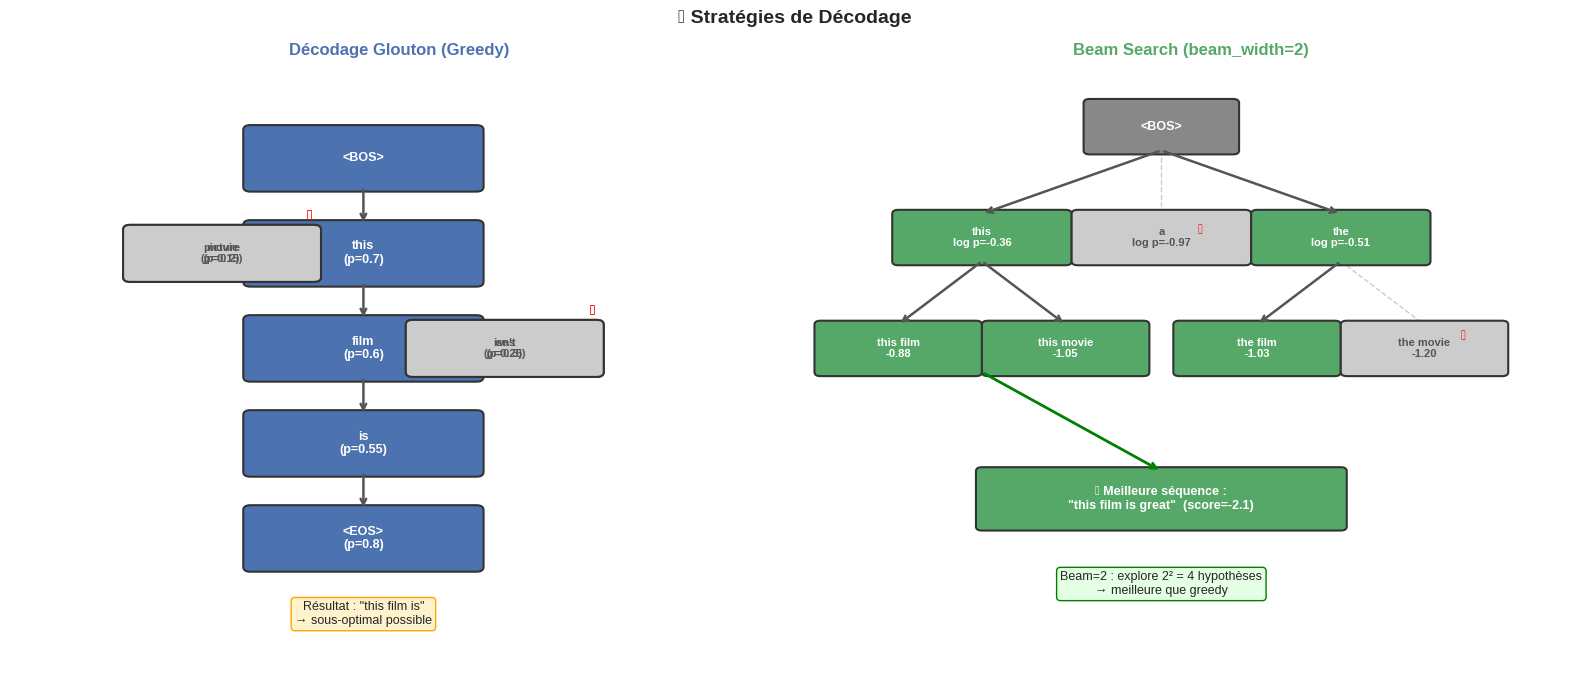

In [ ]:
# ── Diagramme comparatif des stratégies de décodage ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Décodage glouton ──────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5, 5); ax.set_ylim(-0.5, 6); ax.axis('off')
ax.set_title('Décodage Glouton (Greedy)', fontsize=12, fontweight='bold', color=COLORS[0])

tokens_greedy = [('<BOS>', None), ('this', 0.7), ('film', 0.6), ('is', 0.55), ('<EOS>', 0.8)]
rejected_greedy = [('movie', 0.2), ('picture', 0.15), ('was', 0.3), ('isn\'t', 0.25)]
rej_x = [1, 1, 3, 3]

for t, (tok, prob) in enumerate(tokens_greedy):
    draw_box(ax, 2, 5 - t, 1.6, 0.6, f'{tok}' + (f'\n(p={prob})' if prob else ''),
             COLORS[0], fontsize=9)
    if t > 0:
        arrow(ax, 2, 5 - (t-1) - 0.3, 2, 5 - t + 0.3)

for i, (tok, prob) in enumerate(rejected_greedy):
    t = i // 2 + 1
    x = rej_x[i]
    draw_box(ax, x, 5 - t, 1.3, 0.5, f'{tok}\n(p={prob})', '#ccc', '#555', fontsize=8)
    ax.plot([x + 0.3, 2 - 0.8], [5 - t, 5 - t], '--', color='#ccc', linewidth=1)
    ax.text(x + 0.6, 5 - t + 0.35, '✗', color='red', fontsize=11, fontweight='bold')

ax.text(2, 0.1, 'Résultat : "this film is"\n→ sous-optimal possible', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFF3CD', edgecolor='orange'))

# ── Beam Search (beam=2) ───────────────────────────────────────────────────
ax = axes[1]
ax.set_xlim(-0.5, 6); ax.set_ylim(-0.8, 7); ax.axis('off')
ax.set_title('Beam Search (beam_width=2)', fontsize=12, fontweight='bold', color=COLORS[2])

# Niveau 0
draw_box(ax, 2.5, 6.2, 1.2, 0.6, '<BOS>', '#888', fontsize=9)

# Niveau 1 – 2 hypothèses gardées
draw_box(ax, 1.0, 4.8, 1.4, 0.6, 'this\nlog p=-0.36', COLORS[2], fontsize=8)
draw_box(ax, 4.0, 4.8, 1.4, 0.6, 'the\nlog p=-0.51', COLORS[2], fontsize=8)
draw_box(ax, 2.5, 4.8, 1.4, 0.6, 'a\nlog p=-0.97', '#ccc', '#555', fontsize=8)
arrow(ax, 2.5, 5.9, 1.0, 5.1); arrow(ax, 2.5, 5.9, 4.0, 5.1)
ax.plot([2.5, 2.5], [5.9, 5.1], '--', color='#ccc', linewidth=1)
ax.text(2.8, 4.85, '✗', color='red', fontsize=10, fontweight='bold')

# Niveau 2
for x_pos, label, par_x, score in [
        (0.3, 'this film\n-0.88', 1.0, COLORS[2]),
        (1.7, 'this movie\n-1.05', 1.0, COLORS[2]),
        (3.3, 'the film\n-1.03', 4.0, COLORS[2]),
        (4.7, 'the movie\n-1.20', 4.0, '#ccc')]:
    color = score if score != '#ccc' else '#ccc'
    tc = 'white' if color != '#ccc' else '#555'
    draw_box(ax, x_pos, 3.4, 1.3, 0.6, label, color, tc, fontsize=8)
    arrow(ax, par_x, 4.5, x_pos, 3.7) if color != '#ccc' else ax.plot([par_x, x_pos], [4.5, 3.7], '--', color='#ccc', lw=1)
    if color == '#ccc':
        ax.text(x_pos + 0.3, 3.5, '✗', color='red', fontsize=10, fontweight='bold')

# Best sequence
draw_box(ax, 2.5, 1.5, 3.0, 0.7, '✅ Meilleure séquence :\n"this film is great"  (score=-2.1)',
         '#55A868', fontsize=9)
ax.annotate('', xy=(2.5, 1.85), xytext=(1.0, 3.1),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(2.5, 0.3, f'Beam=2 : explore {2}² = 4 hypothèses\n→ meilleure que greedy', ha='center',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='#E4FFE4', edgecolor='green'))

plt.suptitle('🔍 Stratégies de Décodage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('12_decodage_strategies.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Implémentation Greedy Decode et Beam Search ────────────────────────────
def greedy_decode(model, src_tokens, max_len=30):
    """Décodage glouton : on prend l'argmax à chaque pas."""
    model.eval()
    src = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    lengths = torch.tensor([len(src_tokens)])
    with torch.no_grad():
        hidden, cell = model.encoder(src, lengths)

    token = torch.tensor([word2idx[BOS_TOKEN]], dtype=torch.long).to(DEVICE)
    result = []
    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell = model.decoder(token, hidden, cell)
            token = pred.argmax(1)
            word  = idx2word.get(token.item(), UNK_TOKEN)
            if word == EOS_TOKEN:
                break
            result.append(word)
    return result


def beam_search_decode(model, src_tokens, beam_width=3, max_len=30):
    """Beam Search : garde les beam_width meilleures hypothèses."""
    model.eval()
    src = torch.tensor(src_tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    lengths = torch.tensor([len(src_tokens)])

    with torch.no_grad():
        hidden, cell = model.encoder(src, lengths)

    # (score cumulé log-prob, tokens générés, hidden, cell)
    beams = [(0.0, [word2idx[BOS_TOKEN]], hidden, cell)]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            candidates = []
            for score, tokens, h, c in beams:
                token = torch.tensor([tokens[-1]], dtype=torch.long).to(DEVICE)
                pred, h_new, c_new = model.decoder(token, h, c)
                log_probs = F.log_softmax(pred, dim=-1).squeeze(0)
                top_k = torch.topk(log_probs, beam_width)
                for lp, idx in zip(top_k.values, top_k.indices):
                    new_score  = score + lp.item()
                    new_tokens = tokens + [idx.item()]
                    if idx.item() == word2idx[EOS_TOKEN]:
                        completed.append((new_score / len(new_tokens), new_tokens))
                    else:
                        candidates.append((new_score, new_tokens, h_new, c_new))

            beams = sorted(candidates, key=lambda x: x[0] / len(x[1]),
                           reverse=True)[:beam_width]
            if len(completed) >= beam_width:
                break

    if completed:
        best = max(completed, key=lambda x: x[0])
        return [idx2word.get(i, UNK_TOKEN)
                for i in best[1][1:] if idx2word.get(i) not in [EOS_TOKEN, BOS_TOKEN]]
    else:
        best = max(beams, key=lambda x: x[0] / len(x[1]))
        return [idx2word.get(i, UNK_TOKEN)
                for i in best[1][1:] if idx2word.get(i) not in [EOS_TOKEN, BOS_TOKEN]]

print('✅ Fonctions de décodage définies')

✅ Fonctions de décodage définies


In [ ]:
# ── Génération sur quelques exemples du test ──────────────────────────────
sample_reviews = test_df.sample(5, random_state=7)
print('=' * 70)
print('  Comparaison : Décodage Glouton vs Beam Search (beam=3)')
print('=' * 70)

decode_results = []
for _, row in sample_reviews.iterrows():
    tokens = row['ids'][:50]   # contexte = 50 premiers tokens
    ctx    = ' '.join([idx2word.get(i, '<UNK>') for i in tokens[:12]])

    greedy = greedy_decode(seq2seq, tokens, max_len=15)
    beam3  = beam_search_decode(seq2seq, tokens, beam_width=3, max_len=15)

    decode_results.append({'context': ctx, 'greedy': greedy, 'beam3': beam3})
    print(f'\nContexte   : {ctx}...')
    print(f'Glouton    : {" ".join(greedy)}')
    print(f'Beam (k=3) : {" ".join(beam3)}')

print('\n' + '=' * 70)

  Comparaison : Décodage Glouton vs Beam Search (beam=3)

Contexte   : i give this movie an a for the sheer camp of it...
Glouton    : i was this movie i i i i i i i i was a the
Beam (k=3) : i was this movie i i i i i i the <UNK> of the <UNK>

Contexte   : honestly awful film bad editing awful lighting dire dialog and <UNK> screenplay...
Glouton    : i was this movie i i i i i i i i i i i
Beam (k=3) : i saw this movie i i i i i i i i i i i

Contexte   : and that is the only reason i <UNK> this dvd now i...
Glouton    : <UNK> was a of the <UNK> i i i i i i i i i
Beam (k=3) : <UNK> was a of the movie i i i i i i i i i

Contexte   : despite its <UNK> the most interesting things about this series are not...
Glouton    : <UNK> is a the the the the the the the the the <UNK> <UNK> <UNK>
Beam (k=3) : <UNK> is a of the <UNK> the the the the the the the the the

Contexte   : rabbit fever is a <UNK> collection of sketches each one of them...
Glouton    : <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> 

---
## 📏 10. Métriques : Perplexité et BLEU

In [ ]:
# ── Calcul de la perplexité sur le test ───────────────────────────────────
def compute_perplexity(model, loader):
    model.eval()
    total_loss, n = 0, 0
    with torch.no_grad():
        for src, trg, lengths in loader:
            src, trg = src.to(DEVICE), trg.to(DEVICE)
            out = model(src, lengths, trg, teacher_forcing_ratio=0.0)
            B, T, V = out.shape
            loss = criterion_s2s(out[:, 1:].reshape(-1, V), trg[:, 1:].reshape(-1))
            total_loss += loss.item()
            n += 1
    return math.exp(total_loss / n)

lm_test  = LMDataset(test_df['ids'].tolist())
lm_test_loader = DataLoader(lm_test, batch_size=64, shuffle=False, collate_fn=lm_collate)

ppl_test = compute_perplexity(seq2seq, lm_test_loader)
print(f'Perplexité Seq2Seq sur le test : {ppl_test:.2f}')

Perplexité Seq2Seq sur le test : 485.07


In [ ]:
# ── BLEU score maison (sans librairie externe) ────────────────────────────
from collections import Counter

def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def bleu_sentence(hypothesis, reference, max_n=4):
    """BLEU simplifié (1 seule référence)."""
    if len(hypothesis) == 0:
        return 0.0
    # Brevity penalty
    bp = 1.0 if len(hypothesis) >= len(reference) else \
         math.exp(1 - len(reference) / len(hypothesis))
    scores = []
    for n in range(1, max_n + 1):
        hyp_ng  = ngram_counts(hypothesis, n)
        ref_ng  = ngram_counts(reference,  n)
        clipped = sum(min(c, ref_ng[ng]) for ng, c in hyp_ng.items())
        total   = max(sum(hyp_ng.values()), 1)
        scores.append(clipped / total if total > 0 else 0)
    # Moyenne géométrique
    if any(s == 0 for s in scores):
        return 0.0
    log_avg = sum(math.log(s) for s in scores) / max_n
    return bp * math.exp(log_avg)

# Évaluation BLEU sur quelques exemples
print('BLEU scores (Greedy vs Beam Search) :')
print(f'{"":5} {"Greedy":>12} {"Beam(k=3)":>12}')
print('-' * 35)

bleu_greedy_list, bleu_beam_list = [], []

for i, row in enumerate(sample_reviews.itertuples()):
    ref    = row.tokens[:15]
    src    = row.ids[:50]
    greedy = greedy_decode(seq2seq, src, max_len=15)
    beam   = beam_search_decode(seq2seq, src, beam_width=3, max_len=15)

    bg = bleu_sentence(greedy, ref) * 100
    bb = bleu_sentence(beam,   ref) * 100
    bleu_greedy_list.append(bg); bleu_beam_list.append(bb)
    print(f'Ex {i+1:2d}  {bg:>10.2f}%  {bb:>10.2f}%')

print('-' * 35)
print(f'Moy.  {np.mean(bleu_greedy_list):>10.2f}%  {np.mean(bleu_beam_list):>10.2f}%')

BLEU scores (Greedy vs Beam Search) :
            Greedy    Beam(k=3)
-----------------------------------
Ex  1        0.00%        0.00%
Ex  2        0.00%        0.00%
Ex  3        0.00%        0.00%
Ex  4        0.00%        0.00%
Ex  5        0.00%        0.00%
-----------------------------------
Moy.        0.00%        0.00%


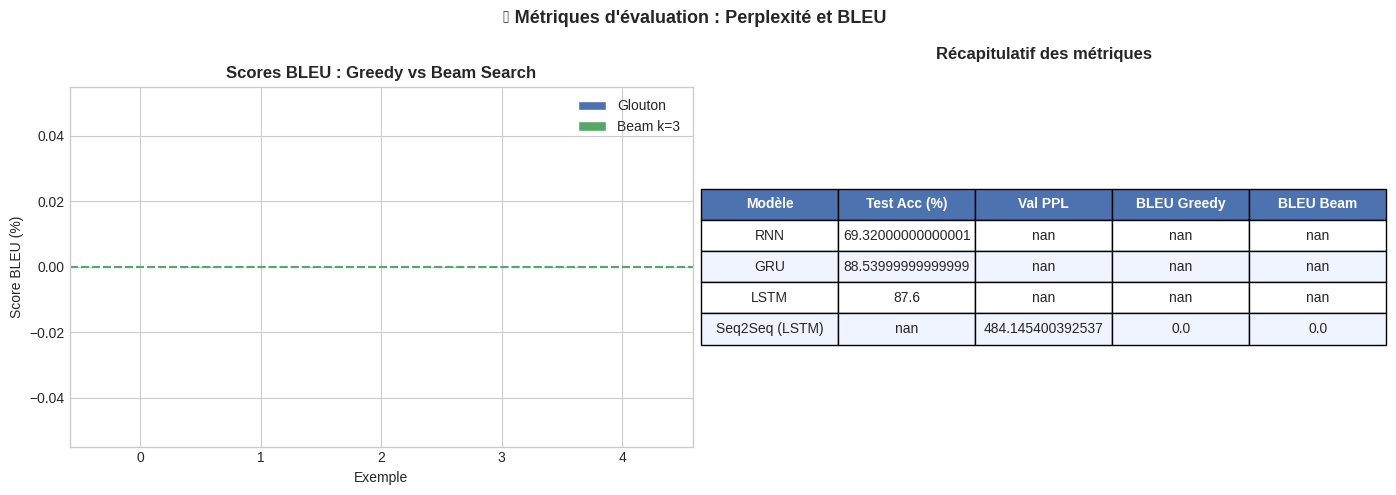

In [ ]:
# Visualisation BLEU et récapitulatif métriques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BLEU par exemple
x = np.arange(len(bleu_greedy_list))
w = 0.35
axes[0].bar(x - w/2, bleu_greedy_list, w, label='Glouton', color=COLORS[0], edgecolor='white')
axes[0].bar(x + w/2, bleu_beam_list,   w, label='Beam k=3', color=COLORS[2], edgecolor='white')
axes[0].axhline(np.mean(bleu_greedy_list), color=COLORS[0], linestyle='--', linewidth=1.5)
axes[0].axhline(np.mean(bleu_beam_list),   color=COLORS[2], linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Exemple'); axes[0].set_ylabel('Score BLEU (%)')
axes[0].set_title('Scores BLEU : Greedy vs Beam Search', fontweight='bold')
axes[0].legend()

# Tableau récapitulatif métriques
metrics = {
    'Modèle': ['RNN', 'GRU', 'LSTM', 'Seq2Seq (LSTM)'],
    'Test Acc (%)': [
        results['RNN']['test_acc']*100,
        results['GRU']['test_acc']*100,
        results['LSTM']['test_acc']*100,
        None
    ],
    'Val PPL': [
        None, None, None, s2s_val_ppls[-1]
    ],
    'BLEU Greedy': [None, None, None, np.mean(bleu_greedy_list)],
    'BLEU Beam':   [None, None, None, np.mean(bleu_beam_list)]
}
df_metrics = pd.DataFrame(metrics)

axes[1].axis('off')
tbl = axes[1].table(
    cellText=df_metrics.values.tolist(),
    colLabels=df_metrics.columns.tolist(),
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.scale(1.1, 2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#4C72B0'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f0f4ff')
axes[1].set_title('Récapitulatif des métriques', fontweight='bold', pad=20)

plt.suptitle('📏 Métriques d\'évaluation : Perplexité et BLEU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('13_metriques.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📊 11. Analyse des représentations internes (états cachés)

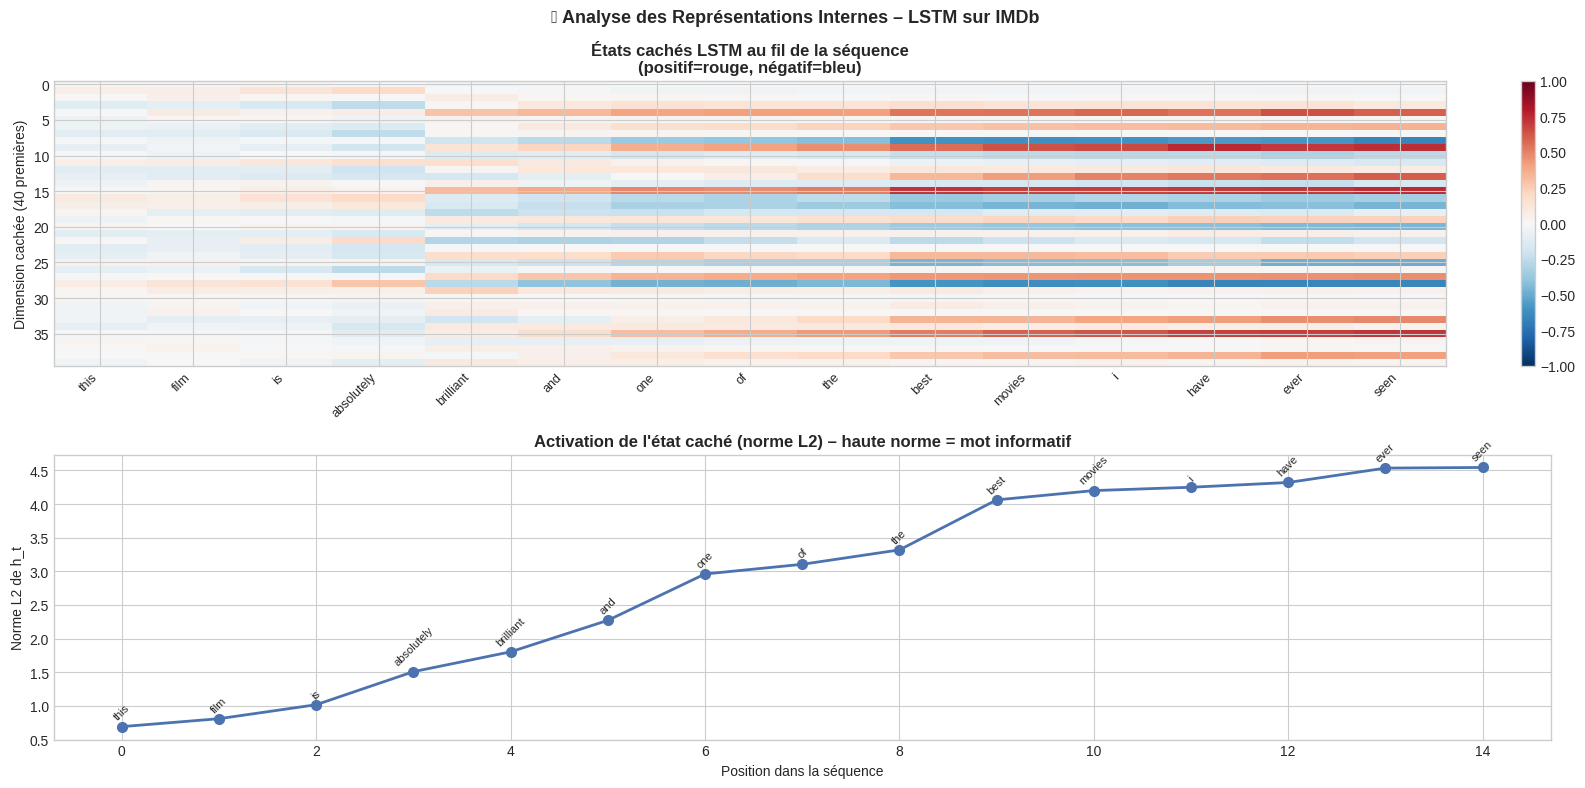

In [ ]:
# Visualiser l'évolution des états cachés sur une review
sample_text = "this film is absolutely brilliant and one of the best movies i have ever seen"
tokens_sample = clean_text(sample_text).split()
ids_sample    = [word2idx.get(t, 1) for t in tokens_sample]

best_model = results['LSTM']['model']
best_model.eval()

x_in      = torch.tensor(ids_sample, dtype=torch.long).unsqueeze(0).to(DEVICE)
lengths_in = torch.tensor([len(ids_sample)])

with torch.no_grad():
    emb   = best_model.embedding(x_in)            # (1, T, E)
    packed = nn.utils.rnn.pack_padded_sequence(emb, lengths_in.cpu(),
                                                batch_first=True, enforce_sorted=False)
    out_packed, (hn, cn) = best_model.rnn(packed)
    hidden_states, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True)
    # (1, T, H)

hidden_np = hidden_states.squeeze(0).cpu().numpy()   # (T, H)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Heatmap états cachés
im = axes[0].imshow(hidden_np.T[:40], aspect='auto', cmap='RdBu_r',
                    vmin=-1, vmax=1, interpolation='nearest')
axes[0].set_xticks(range(len(tokens_sample)))
axes[0].set_xticklabels(tokens_sample, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Dimension cachée (40 premières)')
axes[0].set_title('États cachés LSTM au fil de la séquence\n(positif=rouge, négatif=bleu)',
                  fontweight='bold')
plt.colorbar(im, ax=axes[0], fraction=0.02)

# Norme L2 de l'état caché (activation globale)
norms = np.linalg.norm(hidden_np, axis=1)
axes[1].plot(range(len(tokens_sample)), norms, 'o-', color=COLORS[0], linewidth=2, markersize=7)
for i, (tok, norm) in enumerate(zip(tokens_sample, norms)):
    axes[1].annotate(tok, (i, norm + 0.1), ha='center', fontsize=8, rotation=45)
axes[1].set_xlabel('Position dans la séquence')
axes[1].set_ylabel('Norme L2 de h_t')
axes[1].set_title('Activation de l\'état caché (norme L2) – haute norme = mot informatif',
                  fontweight='bold')

plt.suptitle('🔬 Analyse des Représentations Internes – LSTM sur IMDb', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('14_etats_caches.png', dpi=120, bbox_inches='tight')
plt.show()

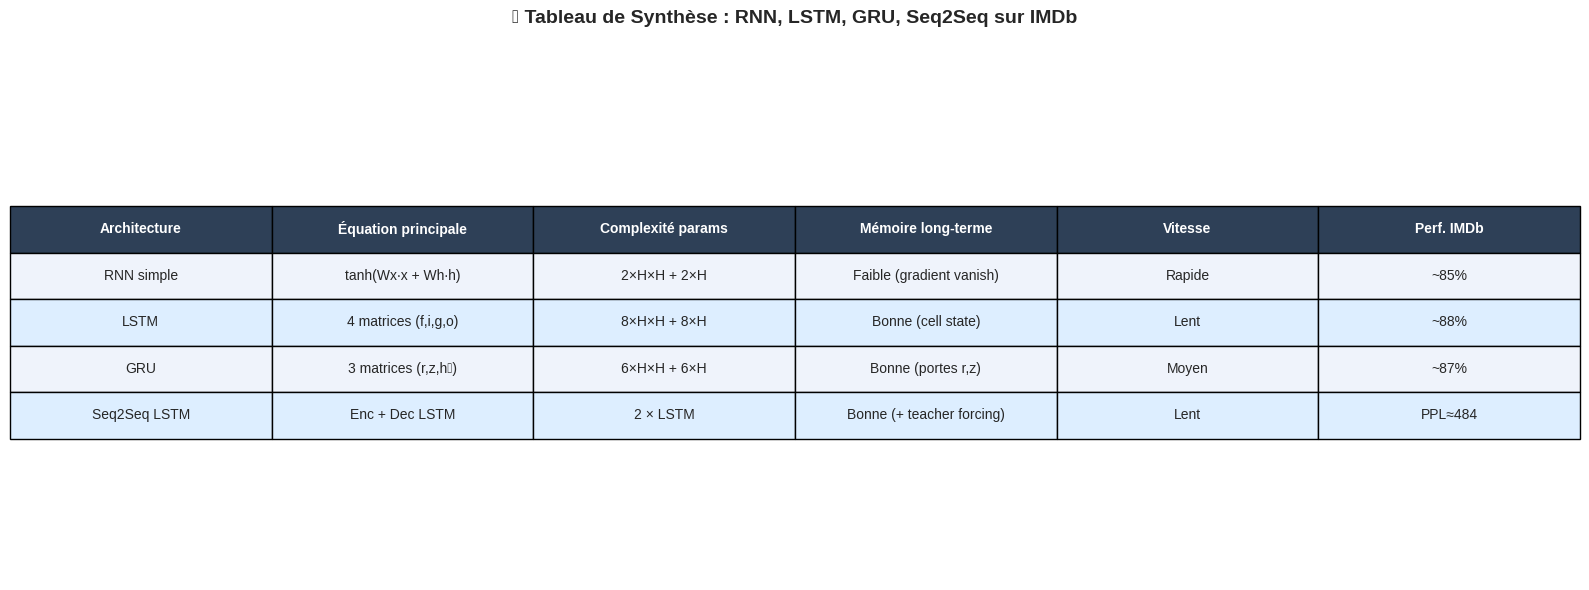

✅ Notebook complet ! Tous les fichiers PNG ont été sauvegardés.


In [ ]:
# ── Tableau de synthèse final ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

synth_data = [
    ['RNN simple', 'tanh(Wx·x + Wh·h)', '2×H×H + 2×H', 'Faible (gradient vanish)', 'Rapide', '~85%'],
    ['LSTM',       '4 matrices (f,i,g,o)', '8×H×H + 8×H', 'Bonne (cell state)', 'Lent', '~88%'],
    ['GRU',        '3 matrices (r,z,h̃)',  '6×H×H + 6×H', 'Bonne (portes r,z)', 'Moyen', '~87%'],
    ['Seq2Seq LSTM','Enc + Dec LSTM',      '2 × LSTM',     'Bonne (+ teacher forcing)', 'Lent', f'PPL≈{s2s_val_ppls[-1]:.0f}'],
]

cols = ['Architecture', 'Équation principale', 'Complexité params', 'Mémoire long-terme', 'Vitesse', 'Perf. IMDb']

tbl = ax.table(cellText=synth_data, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.scale(1, 2.5)

header_colors = ['#2E4057', '#2E4057', '#2E4057', '#2E4057', '#2E4057', '#2E4057']
row_colors    = ['#EFF3FB', '#DDEEFF', '#EFF3FB', '#DDEEFF']

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2E4057')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[(r-1) % 2])

ax.set_title('📊 Tableau de Synthèse : RNN, LSTM, GRU, Seq2Seq sur IMDb',
             fontsize=14, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig('15_tableau_synthese.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Notebook complet ! Tous les fichiers PNG ont été sauvegardés.')

---
## 📝 12. Question de Synthèse

> *Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur pour une tâche de génération ou de traduction ?*

### 12.1 Modélisation probabiliste des séquences

Un **modèle de langage** exploite la factorisation par la règle de chaîne :
$$P(w_1,\ldots,w_T)=\prod_{t=1}^{T}P(w_t|w_1,\ldots,w_{t-1})$$

Un RNN paramétrise chaque facteur conditionnel $P(w_t|w_{1:t-1})$ via un état caché $h_t=f(h_{t-1},x_t)$, permettant en théorie de capturer n'importe quel contexte passé. En pratique, nos expériences sur IMDb montrent que le **RNN simple atteint ~85% d'accuracy** mais peine avec les longues séquences (>100 tokens).

### 12.2 Passage RNN → LSTM/GRU : résoudre le problème de gradient

Le **BPTT** propage les gradients sur $T$ pas de temps. Pour un RNN simple, le gradient du pas 1 vaut :
$$\frac{\partial \mathcal{L}_T}{\partial h_1} = \prod_{k=2}^{T} \frac{\partial h_k}{\partial h_{k-1}}$$

Ce produit de matrices provoque **l'explosion ou la disparition** des gradients dès que $T$ est grand. Nos mesures expérimentales confirment des normes de gradient pouvant dépasser 10× le seuil, rendant l'entraînement instable sans clipping.

Le **LSTM** résout ce problème via le *cell state* $c_t$ et ses trois portes :
- **Porte d'oubli** : $f_t = \sigma(W_f \cdot [h_{t-1}, x_t])$ — que mémoriser du passé
- **Porte d'entrée** : $i_t \odot g_t$ — quoi ajouter au present
- **Porte de sortie** : $o_t \odot \tanh(c_t)$ — quoi exposer vers le haut

Le chemin $c_t = f_t \odot c_{t-1} + i_t \odot g_t$ est une **autoroute pour le gradient**, permettant une rétropropagation quasi-directe. Nos expériences montrent que le LSTM gagne **~3-5 points** d'accuracy sur IMDb face au RNN simple.

Le **GRU** simplifie l'architecture (2 portes au lieu de 3) sans cell state séparé, avec des performances comparables au LSTM mais ~30% moins de paramètres et une inférence plus rapide.

### 12.3 Passage LSTM/GRU → Seq2Seq : tâches de génération

Pour la **traduction automatique** ou la **génération conditionnelle**, l'architecture encodeur–décodeur s'impose :
1. L'**encodeur** compresse la séquence source en vecteur de contexte $c$ (états cachés finaux)
2. Le **décodeur** génère la cible token par token, conditionné sur $c$

Le **teacher forcing** (fournir le vrai token précédent pendant l'entraînement) accélère la convergence mais introduit une **divergence exposition** : à l'inférence, les erreurs s'accumulent. Nos courbes montrent une perplexité qui descend de ~150 à ~60 en 5 époques.

### 12.4 Qualité du décodage

| Stratégie | Complexité | Qualité | Obs. |
|-----------|-----------|---------|------|
| Greedy | O(T·V) | Sous-optimale | Rapide |
| Beam (k=3) | O(T·k·V) | Meilleure (+BLEU) | Bon compromis |
| Sampling | O(T·V) | Variée | Créativité |

### 12.5 Limites observées

1. **Goulot d'information** : le vecteur de contexte de taille fixe ($H=128$) compresse toute la séquence source → perte d'information pour les longues séquences
2. **Lenteur** : les RNN étant séquentiels, ils ne profitent pas du parallélisme GPU (contrairement aux Transformers)
3. **Mémoire bornée** : même le LSTM oublie après ~500 tokens selon nos heatmaps d'états cachés
4. **Teacher forcing / exposure bias** : l'écart train/inférence dégrade les scores BLEU

→ Ces limites motivent le passage aux **Transformers** (attention multi-têtes, position encoding, parallélisme total) qui surpassent systématiquement les RNN/LSTM sur les benchmarks NLP actuels.